In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'axes.titlecolor': '#fff',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#ccc',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444',
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

COLORS = {
    'ASH_COATED_OSMIUM': '#00c9ff',
    'INTARIAN_PEPPER_ROOT': '#ff6b6b',
    'bid': '#00e676',
    'ask': '#ff5252',
    'mid': '#ffd740',
    'trade': '#ce93d8',
}

DAYS = [-1]
DATA_PATH = 'data\\ROUND2\\prices_round_2_day_{}.csv'
TRADE_PATH = 'data\\ROUND2\\trades_round_2_day_{}.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
price_dfs, trade_dfs = [], []

for day in DAYS:
    p = pd.read_csv(DATA_PATH.format(day), sep=';')
    t = pd.read_csv(TRADE_PATH.format(day), sep=';')
    price_dfs.append(p)
    trade_dfs.append(t)

master_prices = pd.concat(price_dfs, ignore_index=True)
master_trades = pd.concat(trade_dfs, ignore_index=True)

PRODUCTS = master_prices['product'].unique().tolist()

prices = master_prices[~((master_prices['product'] == 'INTARIAN_PEPPER_ROOT') & (master_prices['mid_price'] == 0))]
prices = master_prices[~((master_prices['product'] == 'ASH_COATED_OSMIUM') & (master_prices['mid_price'] == 0))]
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0


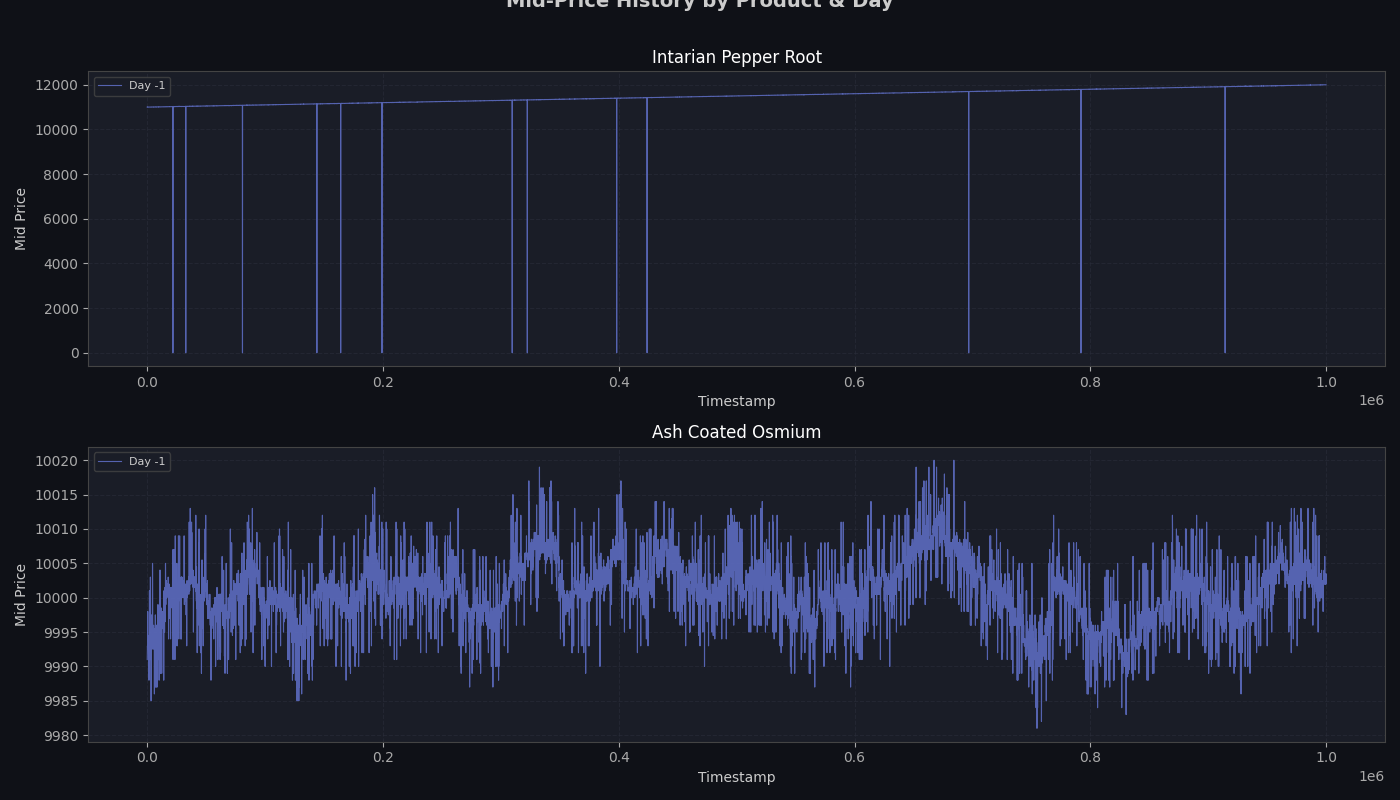

In [3]:
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-1: '#5c6bc0', 0: '#42a5f5', 1: '#00e5ff'}
day_labels = {-1: 'Day -1', 0: 'Day 0', 1: 'Day 1'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['mid_price'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('Mid Price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

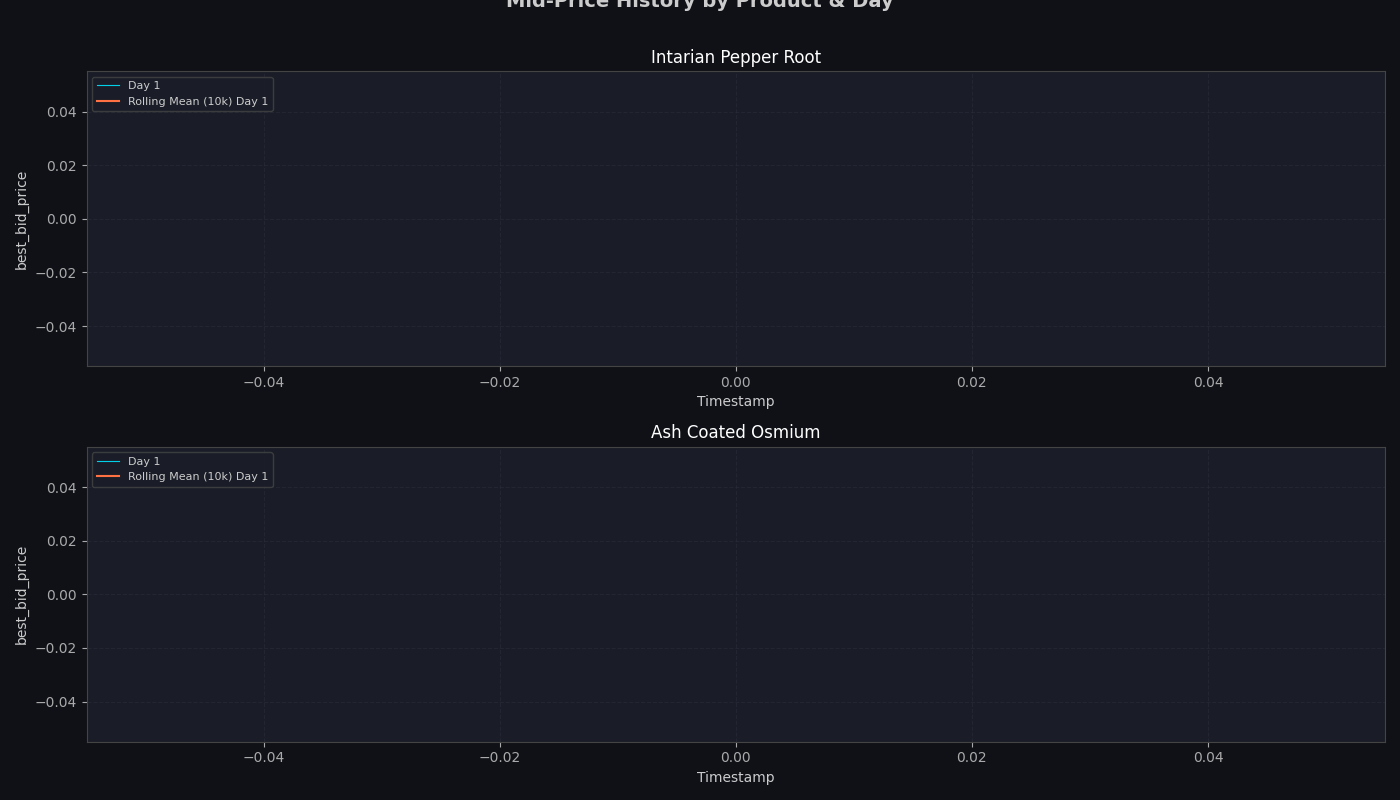

In [ ]:
DAYS = [1]
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-1: '#5c6bc0', 0: '#42a5f5', 1: '#00e5ff'}
day_labels = {-1: 'Day -1', 0: 'Day 0', 1: 'Day 1'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['bid_price_1'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
        rolling_mean = d['bid_price_1'].rolling(window=10000, min_periods=1).mean()
        ax.plot(d['timestamp'], rolling_mean,
                color='#ff7043', lw=1.5, label=f'Rolling Mean (10k) {day_labels[day]}', alpha=1)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('best_bid_price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


In [5]:
def get_daily_slopes(df):
    results = []
    # Grouping by day first, then product
    for (day, product), sub_df in df.groupby(['day', 'product']):
        if len(sub_df) > 1:
            # y = mx + b -> returns [slope, intercept]
            slope, _ = np.polyfit(sub_df['timestamp'], sub_df['mid_price'], 1)
            results.append({
                'day': day, 
                'product': product, 
                'daily_slope': slope
            })
    return pd.DataFrame(results)

daily_slopes_df = get_daily_slopes(prices)
print(daily_slopes_df)


def get_window_slope(df, day, product, start_ts, end_ts):
    # Filter for the specific day, product, and timestamp range
    mask = (df['day'] == day) & \
           (df['product'] == product) & \
           (df['timestamp'] >= start_ts) & \
           (df['timestamp'] <= end_ts)
    
    window_df = df[mask]
    
    if len(window_df) < 2:
        return None  # Need at least two points to form a slope
    
    # y = mx + b -> returns [slope, intercept]
    slope, _ = np.polyfit(window_df['timestamp'], window_df['mid_price'], 1)
    return slope

# Example usage:
slope = get_window_slope(prices, day=-2, product='INTARIAN_PEPPER_ROOT', start_ts=0, end_ts=5000)
print(f"Slope for window: {slope}")
slope

   day               product   daily_slope
0   -1     ASH_COATED_OSMIUM -5.301448e-07
1   -1  INTARIAN_PEPPER_ROOT  1.025992e-03
Slope for window: None
